# Chapter 2 – Pandas, NumPy, and Matplotlib  
## Part 2: NumPy Foundations and Data Visualization with Matplotlib

### Overview
This notebook provides a lightweight introduction to **NumPy** and **Matplotlib**, two core libraries that underpin most of the Python data science and bioinformatics ecosystem. While NumPy is often used indirectly through libraries such as pandas, Biopython, and scikit-learn, understanding its role as the numerical engine behind these tools is essential for effective scientific computing.

Using **VAERS (Vaccine Adverse Event Reporting System)** data as a case study, this notebook demonstrates how NumPy arrays support common analytical workflows and how Matplotlib can be used to generate publication-quality visualizations relevant to epidemiological and biomedical data analysis.

### Scope
In this notebook, we:
- Highlight NumPy’s role in numerical computation and data manipulation
- Use NumPy concepts indirectly through pandas operations
- Aggregate VAERS data by U.S. state and age groups
- Generate charts using Matplotlib to summarize and visualize epidemiological patterns

This notebook focuses on conceptual understanding and practical usage rather than an exhaustive treatment of either library.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vdata = pd.read_csv(
    "vdata_sample.csv.gz", encoding="iso-8859-1")

vdata["STATE"] = vdata["STATE"].str.upper()
top_states = pd.DataFrame({
    "size": vdata.groupby("STATE").size().sort_values(ascending=False).head(5)}).reset_index()
top_states["rank"] = top_states.index
top_states = top_states.set_index("STATE")
top_vdata = vdata[vdata["STATE"].isin(top_states.index)]
top_vdata["state_code"] = top_vdata["STATE"].apply(
    lambda state: top_states["rank"].at[state]
).astype(np.uint8)
top_vdata = top_vdata[top_vdata["AGE_YRS"].notna()]
top_vdata.loc[:,"AGE_YRS"] = top_vdata["AGE_YRS"].astype(int)
top_states

C:\Users\razon\AppData\Local\Temp\ipykernel_29232\1193892248.py:5: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  vdata = pd.read_csv(
C:\Users\razon\AppData\Local\Temp\ipykernel_29232\1193892248.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vdata["state_code"] = top_vdata["STATE"].apply(


,size,rank
STATE,,
CA,64055,0
FL,37973,1
TX,37577,2
NY,35986,3
PA,23983,4


In [10]:
age_state = top_vdata[["state_code", "AGE_YRS"]]
age_state["state_code"]
state_code_arr = age_state["state_code"].values
type(state_code_arr), state_code_arr.shape, state_code_arr.dtype

age_state["AGE_YRS"]
age_arr = age_state["AGE_YRS"].values
type(age_arr), age_arr.shape, age_arr.dtype

(numpy.ndarray, (182528,), dtype('float64'))

In [15]:
age_state_mat = np.zeros((5, 6), dtype=np.uint64)

for row in age_state.itertuples():
    if pd.notnull(row.AGE_YRS) and pd.notnull(row.state_code):
        age_bin = min(int(row.AGE_YRS) // 20, 5)  # cap at 5 (100+)
        state_code = int(row.state_code)          # ensure it's int
        age_state_mat[state_code, age_bin] += 1

In [16]:
 cal = age_state_mat[0,:]

In [17]:
kids = age_state_mat[:,0]

In [20]:
def compute_frac(arr_1d):
    return arr_1d / arr_1d.sum()

frac_age_stat_mat = np.apply_along_axis(compute_frac, 1, age_state_mat)
frac_age_stat_mat

array([[8.73353528e-02, 2.74565195e-01, 3.36016473e-01, 2.60474456e-01,
        4.12000953e-02, 4.08427215e-04],
       [4.33100640e-02, 1.89237929e-01, 3.01425247e-01, 3.92699244e-01,
        7.29784759e-02, 3.49040140e-04],
       [8.47855034e-02, 2.81421872e-01, 3.53644416e-01, 2.44746136e-01,
        3.53152319e-02, 8.68407341e-05],
       [7.16862314e-02, 2.77849107e-01, 3.32018831e-01, 2.71857422e-01,
        4.62215701e-02, 3.66837858e-04],
       [6.67028200e-02, 2.58721981e-01, 3.39795734e-01, 2.91395517e-01,
        4.31127983e-02, 2.71149675e-04]])

In [21]:
perc_age_stat_mat = frac_age_stat_mat * 100
perc_age_stat_mat = perc_age_stat_mat.astype(np.uint8)
perc_age_stat_mat

array([[ 8, 27, 33, 26,  4,  0],
       [ 4, 18, 30, 39,  7,  0],
       [ 8, 28, 35, 24,  3,  0],
       [ 7, 27, 33, 27,  4,  0],
       [ 6, 25, 33, 29,  4,  0]], dtype=uint8)

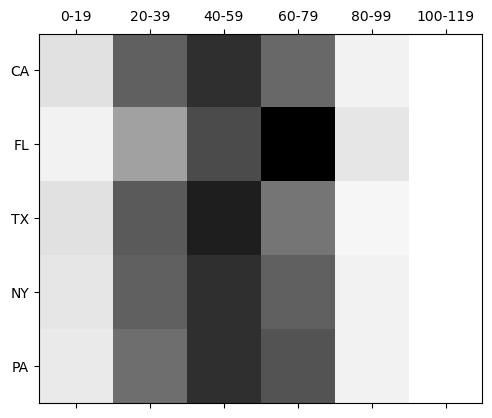

In [22]:
fig = plt.figure()
ax = fig.add_subplot()
ax.matshow(perc_age_stat_mat, cmap=plt.get_cmap("Greys"))
ax.set_yticks(range(5))
ax.set_yticklabels(top_states.index)
ax.set_xticks(range(6))
ax.set_xticklabels(["0-19", "20-39", "40-59", "60-79", "80-99", "100-119"])
fig.savefig("matrix.png")

In [23]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

vdata = pd.read_csv(
    "vdata_sample.csv.gz", encoding="iso-8859-1",
    usecols=lambda name: name != "SYMPTOM_TEXT")

num_rows = len(vdata)
perc_nan = {}
for col_name in vdata.columns:
    num_nans = len(vdata[col_name][vdata[col_name].isna()])
    perc_nan[col_name] = 100 * num_nans / num_rows
labels = perc_nan.keys()
bar_values = list(perc_nan.values())
x_positions = np.arange(len(labels))

C:\Users\razon\AppData\Local\Temp\ipykernel_29232\1241758647.py:6: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  vdata = pd.read_csv(


C:\Users\razon\AppData\Local\Temp\ipykernel_29232\19979538.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


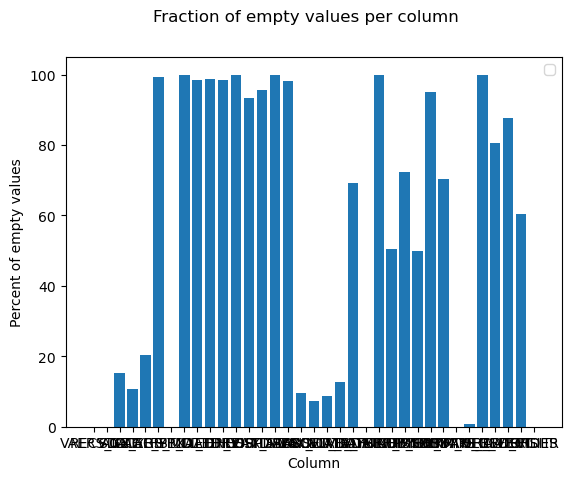

In [25]:
fig = plt.figure()
fig.suptitle("Fraction of empty values per column")
ax = fig.add_subplot()
ax.bar(x_positions, bar_values)
ax.set_ylabel("Percent of empty values")
ax.set_xlabel("Column")
ax.set_xticks(x_positions)
ax.set_xticklabels(labels)
ax.legend()
fig.savefig("naive_chart.png")

In [26]:
fig = plt.figure(figsize=(16, 9), tight_layout=True, dpi=600)
fig.suptitle("Fraction of empty values per column", fontsize="48")
ax = fig.add_subplot()
b1 = ax.bar(x_positions, bar_values)
ax.set_ylabel("Percent of empty values", fontsize="xx-large")
ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.set_xlim(-0.5, len(labels))
for i, x in enumerate(x_positions):
    ax.text(
        x, 2, "%.1f" % bar_values[i], rotation=90,
        va="bottom", ha="center",
        backgroundcolor="white")
fig.text(0.2, 0.01, "Column", fontsize="xx-large")
fig.savefig("cleaner_chart.png")

In [53]:
dead = vdata[vdata.DIED == "Y"]
vax = pd.read_csv("C:/Users/razon/Downloads/2021VAERSData/2021VAERSVAX.zip", encoding="iso-8859-1").set_index("VAERS_ID")

vax.groupby("VAX_TYPE").size().sort_values()

vax_dead = dead.join(vax, on="VAERS_ID", how="inner", lsuffix='_dead', rsuffix='_vax')

# join on id, discuss


vax_dead.iloc[0]

dead_counts = vax_dead["VAX_TYPE"].value_counts()
large_values = dead_counts[dead_counts >= 10]
other_sum = dead_counts[dead_counts < 10].sum()
large_values = pd.concat([large_values, pd.Series({"OTHER": other_sum})])

distance_df = vax_dead[vax_dead.DATEDIED.notna() & vax_dead.VAX_DATE.notna()]
distance_df["DATEDIED"] = pd.to_datetime(distance_df["DATEDIED"])
distance_df["VAX_DATE"] = pd.to_datetime(distance_df["VAX_DATE"])
distance_df = distance_df[distance_df.DATEDIED >= "2021"]
distance_df = distance_df[distance_df.VAX_DATE >= "2021"]
distance_df = distance_df[distance_df.DATEDIED >= distance_df.VAX_DATE]
time_distances = distance_df["DATEDIED"] - distance_df["VAX_DATE"]
time_distances_d = time_distances.dt.total_seconds() / (60 * 60 * 24)

date_died = pd.to_datetime(vax_dead[vax_dead.DATEDIED.notna()]["DATEDIED"])
date_died = date_died[date_died >= "2021"]
date_died_counts = date_died.value_counts().sort_index()
cum_deaths = date_died_counts.cumsum()

state_dead = vax_dead[vax_dead["STATE"].notna()][["STATE", "SEX"]]
top_states = sorted(state_dead["STATE"].value_counts().head(10).index)
top_state_dead = state_dead[state_dead["STATE"].isin(top_states)].groupby(["STATE", "SEX"]).size()#.reset_index()
top_state_dead.loc["MN", "U"] = 0  # XXXX
top_state_dead = top_state_dead.sort_index().reset_index()
top_state_females = top_state_dead[top_state_dead.SEX == "F"][0]
top_state_males = top_state_dead[top_state_dead.SEX == "M"][0]
top_state_unk = top_state_dead[top_state_dead.SEX == "U"][0]

C:\Users\razon\AppData\Local\Temp\ipykernel_29232\2987084297.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  distance_df["DATEDIED"] = pd.to_datetime(distance_df["DATEDIED"])
C:\Users\razon\AppData\Local\Temp\ipykernel_29232\2987084297.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  distance_df["VAX_DATE"] = pd.to_datetime(distance_df["VAX_DATE"])


In [54]:
fig, ((vax_cnt, time_dist), (death_time, state_reps)) = plt.subplots(
    2, 2,
    figsize=(16, 9), tight_layout=True, dpi=600)

vax_cnt.set_title("Vaccines involved in deaths")

wedges, texts = vax_cnt.pie(large_values)
vax_cnt.legend(wedges, large_values.index, loc="lower left")

time_dist.hist(time_distances_d, bins=50)
time_dist.set_title("Days between vaccine administration and death")
time_dist.set_xlabel("Days")
time_dist.set_ylabel("Observations")

death_time.plot(date_died_counts.index, date_died_counts, ".")
death_time.set_title("Deaths over time")
death_time.set_ylabel("Daily deaths")
death_time.set_xlabel("Date")
tw = death_time.twinx()
tw.plot(cum_deaths.index, cum_deaths)
tw.set_ylabel("Cummulative deaths")

state_reps.set_title("Deaths per state stratified by sex")
state_reps.bar(top_states, top_state_females, label="Females")
state_reps.bar(top_states, top_state_males, label="Males", bottom=top_state_females)
state_reps.bar(top_states, top_state_unk, label="Unknown",
               bottom=top_state_females.values + top_state_males.values)
state_reps.legend()
state_reps.set_xlabel("State")
state_reps.set_ylabel("Deaths")

fig.savefig("summary.png")

fig